In [1]:
'''Analisis of equivalency groups on conflict basis'''
# take care about param types
import re
#import functions_is as fis

import numpy as np
import pandas as pd
import string # for int2base

from itertools import product
from itertools import combinations
import itertools
import timeit
import datetime
import copy
from collections import Counter

from gurobipy import *
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
def listToString(list1):
    return (''.join(map(str, list1)))
def listToString_cmm(list1):
    return (','+','.join(map(str, list1))+',')

def list_getsome(vec, positions):
    list_n = []
    for y in positions:
        list_n.append(vec[y])
    #print("lnf", list_n)
    return(list_n)

def diversity_num(vec, dim):
    # return num of different digits without nans
    # быстрее будет удалить сперва наны
    dvst = 0
    for i in range(0, dim):
        for j in range(0, len(vec)):
            if vec[j] == i:
                dvst += 1
                break
    return dvst
#len(set(tbl_merged[~np.isnan(tbl_merged[:,p]),p]))

def diversity_vec(vec, dim):
    dvst = []
    for i in range(0, dim):
        for j in range(0, len(vec)):
            if vec[j] == i:
                dvst.append(i)
                break
    return dvst

# diversity_vec_wnan # from collections import Counter
lst1 = Counter().keys() 
list()
    


[]

In [3]:
#data_ini = pd.read_csv('210805_postcode35_data_l6.csv', sep=';', header=None)
#data_ini = pd.read_csv('02_arctic_5x3_201223_data.csv', sep=';', header=None)
#data_ini = pd.read_excel('02_arctic_5x3_201223_data.xlsx', sheet_name = 'examples')
#data_ini = pd.read_excel('02_arctic_5x3_201223_data_111111.xlsx', sheet_name = 'examples')
#data_ini = pd.read_excel('02_arctic_5x3_201223_data_изменены_4_строчки.xlsx', sheet_name = 'examples')
#data_ini = pd.read_csv('freeley_tab_d4_cl.csv', sep=';', header=None) # table w dubles
#data_ini = pd.read_csv('freeley_tab_d4_cl3_h.csv', sep=';')
#data_ini = pd.read_csv('210917_Id_RealEstate_clearData.csv', sep=';', header=None)
#data_ini = pd.read_csv('210917_Id_RealEstate_DatawHeader.csv', sep=';')
#data_ini = pd.read_excel('221006_nir_data_70_1.xlsx', sheet_name = 'Sheet1')
data_ini = pd.read_excel('210916_football_data8.xlsx', sheet_name = 'tbl')
data_ini = data_ini[['l1', 'l2', 'l3', 'l4','K']]
print(data_ini)
# data should contain only leaves and K columns, it is format
#data_ini = data_ini.drop([31])
# test if there are duplicates 
#data_ini = data_ini.drop_duplicates([0, 1, 2, 3, 4])

# data_ini = data_ini.drop_duplicates(['l1', 'l2', 'l3', 'l4'])
# data_ini.reset_index(inplace = True, drop = True) 
# print(data_ini)
#print(data_ini[data_ini.iloc[:,1:8].duplicated(keep = False)])

   l1  l2  l3  l4  K
0   0   0   0   0  0
1   0   1   0   0  1
2   1   1   0   0  0
3   0   0   1   0  1
4   1   1   1   0  1
5   0   1   0   1  1
6   1   0   1   1  0
7   1   1   1   1  0


lnum =  4
dim =  2


number of set | set length | set on x leaves
--------------------------------------------
  1 |   6 | [(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]
  2 |   4 | [(1, 2, 3), (1, 2, 4), (1, 3, 4), (2, 3, 4)]
group of leaves investigated:  (1, 2)
[[ 0.  1.  2.  3.  4.]
 [ 1.  0.  1. nan nan]
 [ 2. nan nan nan  0.]
 [ 3.  1. nan  1. nan]
 [ 4.  0.  1. nan  0.]]
1  0 0 0.0
2  1 0 nan
2  2 0 1.0
2  3 0 0.0
1  0 1 1.0
2  1 1 nan
2  2 1 nan
2  3 1 1.0
1  0 2 nan
1  1 0 nan
1  1 1 nan
1  1 2 nan


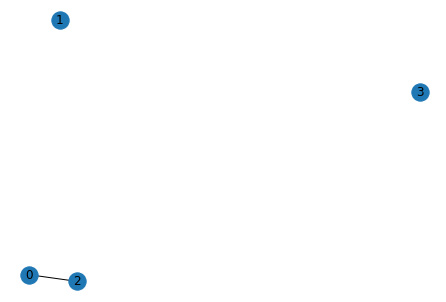

Gurobi Optimizer version 9.5.0 build v9.5.0rc5 (win64)
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads
Optimize a model with 14 rows, 10 columns and 28 nonzeros
Model fingerprint: 0x748656e5
Variable types: 0 continuous, 10 integer (10 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 14 rows and 10 columns
Presolve time: 0.00s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.00 seconds (0.00 work units)
Thread count was 1 (of 16 available processors)

Solution count 1: 2 

Optimal solution found (tolerance 1.00e-04)
Best objective 2.000000000000e+00, best bound 2.000000000000e+00, gap 0.0000%
chrom_num =  2.0
group of leaves investigated:  (1, 3)
[[ 0.  1.  2.  3.  4.]
 [ 1.  0.  1. nan  1.]
 [ 2. nan  0. nan nan]
 [ 3.  1. nan nan nan]
 [ 4. nan  1.  0.  0.]]
1  0 0 0.0
2  1 0 nan
2  2 

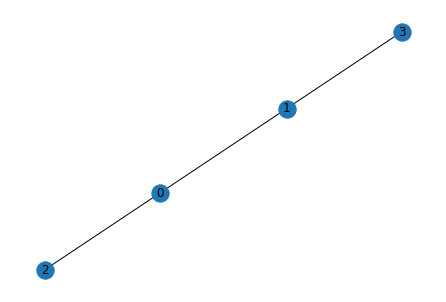

Gurobi Optimizer version 9.5.0 build v9.5.0rc5 (win64)
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads
Optimize a model with 25 rows, 15 columns and 54 nonzeros
Model fingerprint: 0xd70c2184
Variable types: 0 continuous, 15 integer (15 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 3.0000000
Presolve removed 12 rows and 0 columns
Presolve time: 0.00s
Presolved: 13 rows, 15 columns, 39 nonzeros
Variable types: 0 continuous, 15 integer (15 binary)

Root relaxation: objective 2.000000e+00, 9 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0     0               0       2.0000000    2.00000  0.00%     -    0s

Explored 1 nodes (9 simplex iterations) in 0.01 

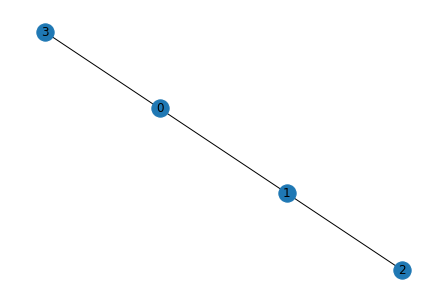

Gurobi Optimizer version 9.5.0 build v9.5.0rc5 (win64)
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads
Optimize a model with 25 rows, 15 columns and 54 nonzeros
Model fingerprint: 0xa583d80f
Variable types: 0 continuous, 15 integer (15 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 3.0000000
Presolve removed 12 rows and 0 columns
Presolve time: 0.00s
Presolved: 13 rows, 15 columns, 39 nonzeros
Variable types: 0 continuous, 15 integer (15 binary)

Root relaxation: objective 2.000000e+00, 9 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0     0               0       2.0000000    2.00000  0.00%     -    0s

Explored 1 nodes (9 simplex iterations) in 0.01 

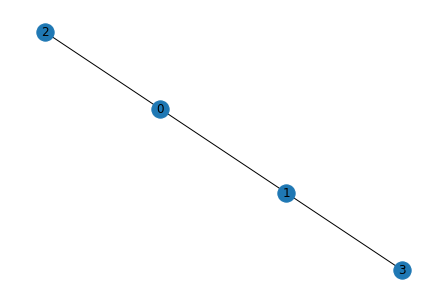

Gurobi Optimizer version 9.5.0 build v9.5.0rc5 (win64)
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads
Optimize a model with 25 rows, 15 columns and 54 nonzeros
Model fingerprint: 0xf42b6e11
Variable types: 0 continuous, 15 integer (15 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 3.0000000
Presolve removed 12 rows and 0 columns
Presolve time: 0.00s
Presolved: 13 rows, 15 columns, 39 nonzeros
Variable types: 0 continuous, 15 integer (15 binary)

Root relaxation: objective 2.000000e+00, 9 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0     0               0       2.0000000    2.00000  0.00%     -    0s

Explored 1 nodes (9 simplex iterations) in 0.01 

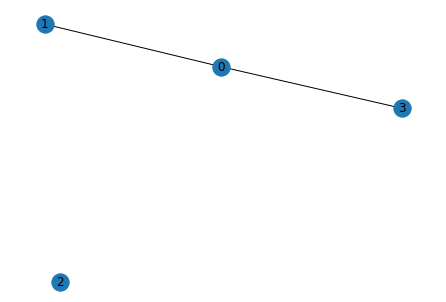

Gurobi Optimizer version 9.5.0 build v9.5.0rc5 (win64)
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads
Optimize a model with 22 rows, 15 columns and 48 nonzeros
Model fingerprint: 0x07a82e4c
Variable types: 0 continuous, 15 integer (15 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 3.0000000
Presolve removed 9 rows and 0 columns
Presolve time: 0.00s
Presolved: 13 rows, 15 columns, 36 nonzeros
Variable types: 0 continuous, 15 integer (15 binary)

Root relaxation: objective 2.000000e+00, 9 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0     0               0       2.0000000    2.00000  0.00%     -    0s

Explored 1 nodes (9 simplex iterations) in 0.01 s

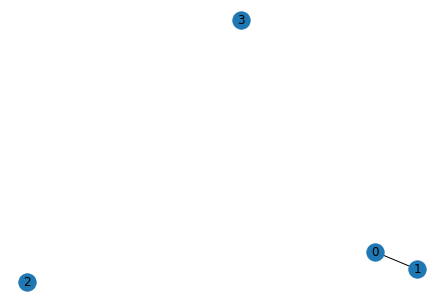

Gurobi Optimizer version 9.5.0 build v9.5.0rc5 (win64)
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads
Optimize a model with 14 rows, 10 columns and 28 nonzeros
Model fingerprint: 0x36e67d55
Variable types: 0 continuous, 10 integer (10 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 14 rows and 10 columns
Presolve time: 0.00s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.00 seconds (0.00 work units)
Thread count was 1 (of 16 available processors)

Solution count 1: 2 

Optimal solution found (tolerance 1.00e-04)
Best objective 2.000000000000e+00, best bound 2.000000000000e+00, gap 0.0000%
chrom_num =  2.0
group of leaves investigated:  (1, 2, 3)
[[ 0.  1.  2.]
 [ 1.  0. nan]
 [ 2.  1.  1.]
 [ 3.  0. nan]
 [ 4.  1. nan]
 [ 5. nan  0.]
 [ 6.  1.  0.]]
1  0 0 0.0
2  1 0 1.0
2  2 0 0.0
2

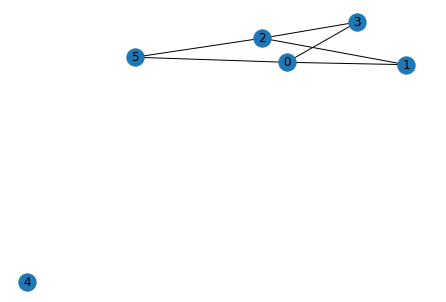

Gurobi Optimizer version 9.5.0 build v9.5.0rc5 (win64)
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads
Optimize a model with 54 rows, 28 columns and 120 nonzeros
Model fingerprint: 0xab25fa56
Variable types: 0 continuous, 28 integer (28 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 3.0000000
Presolve removed 20 rows and 0 columns
Presolve time: 0.00s
Presolved: 34 rows, 28 columns, 104 nonzeros
Variable types: 0 continuous, 28 integer (28 binary)

Root relaxation: objective 2.000000e+00, 20 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0     0               0       2.0000000    2.00000  0.00%     -    0s

Explored 1 nodes (20 simplex iterations) in 0

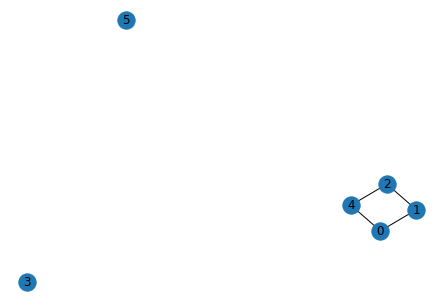

Gurobi Optimizer version 9.5.0 build v9.5.0rc5 (win64)
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads
Optimize a model with 36 rows, 21 columns and 78 nonzeros
Model fingerprint: 0xb9968e9d
Variable types: 0 continuous, 21 integer (21 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 2.0000000
Presolve removed 12 rows and 0 columns
Presolve time: 0.00s
Presolved: 24 rows, 21 columns, 66 nonzeros
Variable types: 0 continuous, 21 integer (21 binary)

Root relaxation: cutoff, 13 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0     cutoff    0         2.00000    2.00000  0.00%     -    0s

Explored 1 nodes (13 simplex iterations) in 0.01 seconds (0.00 

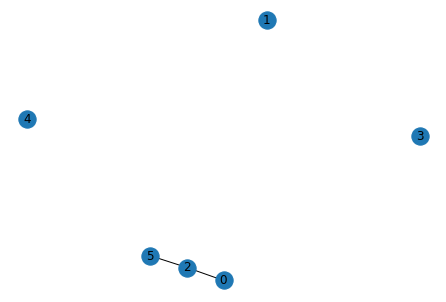

Gurobi Optimizer version 9.5.0 build v9.5.0rc5 (win64)
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads
Optimize a model with 30 rows, 21 columns and 66 nonzeros
Model fingerprint: 0xcfdc5f88
Variable types: 0 continuous, 21 integer (21 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 3.0000000
Presolve removed 9 rows and 0 columns
Presolve time: 0.00s
Presolved: 21 rows, 21 columns, 54 nonzeros
Variable types: 0 continuous, 21 integer (21 binary)

Root relaxation: objective 2.000000e+00, 12 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0     0               0       2.0000000    2.00000  0.00%     -    0s

Explored 1 nodes (12 simplex iterations) in 0.01

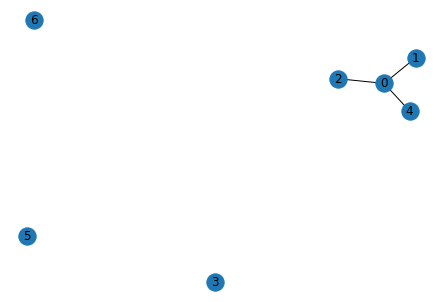

Gurobi Optimizer version 9.5.0 build v9.5.0rc5 (win64)
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads
Optimize a model with 47 rows, 32 columns and 108 nonzeros
Model fingerprint: 0x74ca7564
Variable types: 0 continuous, 32 integer (32 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 4.0000000
Presolve removed 16 rows and 0 columns
Presolve time: 0.00s
Presolved: 31 rows, 32 columns, 88 nonzeros
Variable types: 0 continuous, 32 integer (32 binary)

Root relaxation: objective 2.000000e+00, 18 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0     0               0       2.0000000    2.00000  0.00%     -    0s

Explored 1 nodes (18 simplex iterations) in 0.

In [12]:
# test if the set of examples can be realised 
# with incopmlete techniqe

lnum = data_ini.shape[1]-1
print("lnum = ", lnum)
data = np.array(data_ini.iloc[:,0:lnum+1])
#print("data: \n" ,data)
dim = 1+data.max()-data.min()
print("dim = ", (data.max()-data.min())+1)
#print("K: " ,data[:,lnum-1])
print("\n")

# all posible values of group numbers
lenumeration = [i for i in range(0,lnum)] 

len_combinations = 0
for i in range(2,lnum):
    lcombinations = list(combinations(range(1, lnum+1), i))
    len_combinations += len(lcombinations)

dfnumofisg = pd.DataFrame(
    {
        "name": np.array(len_combinations, dtype="str"),
        "val": np.empty(len_combinations, dtype="int32"),
    }
)

print("number of set | set length | set on x leaves")
print('{message:{fill}{align}{width}}'.format(
   message='',
   fill='-',
   align='<',
   width=44,
))

cnt = 0
for i in range(2,lnum):
    lcombinations = list(combinations(range(1, lnum+1), i))
    # posible combinatins of groups
    print("{0:3} |".format(i-1), end = ' ')
    print("{0:3} |".format(len(lcombinations)), end = ' ')
    #print(i-1, "|", len(lcombinations), "|", lcombinations)
    print(lcombinations)
    for j in range(len(lcombinations)):
        dfnumofisg.iat[cnt,0] = ' '.join(map(str, lcombinations[j]))
        dfnumofisg.iat[cnt,1] = 0
        #print("dfnumofisg[i] ", dfnumofisg.iloc[cnt,:])
        cnt += 1

# form table K
cntisgstore = 0
for numofgroup in range(2,lnum):
    lcombinations = list(combinations(range(0, lnum), numofgroup))
    lcombinations_p = list(combinations(range(1, lnum+1), numofgroup))
    #print("lcombinations", lcombinations)
    for numberofvalue in range(0, len(lcombinations)):
        print("group of leaves investigated: ", lcombinations_p[numberofvalue])
        tbl_k = np.empty((dim**(numofgroup),dim**(lnum-numofgroup)))
        tbl_k.fill(np.nan)
        colfilled = []
        seen = set()
        # fill table K from data string by sting (x)
        for x in range(0,len(data)):
            #print(data[x,lcombinations[j]])
            # get coordinate in nondecimal representation of string
            data[x,lcombinations[numberofvalue]]
            # get coordinate in nondecimal representation of column
            reminder = list(set(lenumeration)-set(lcombinations[numberofvalue])) 
            data[x,reminder]
            # need to place F value in Ktable to selected coordinates
            c1 = "".join([str(xx) for xx in data[x,lcombinations[numberofvalue]]])
            c2 = "".join([str(xx) for xx in data[x,reminder]])
            c2_t = int(c2[::-1], base = dim)
            tbl_k[int(c1[::-1], base = dim), c2_t] = data[x,lnum]
            # попутно можно записать все столбцы в которых есть значения, соотв. другие м.б. удал.
            if c2_t not in seen:
                seen.add(c2_t)
                colfilled.append(c2_t) 
        colfilled.sort()
        tbl_k_s = tbl_k[:,colfilled]
        # del nan rows
        rows_nan = np.all(np.isnan(tbl_k_s), axis = (1))
        tbl_k_s = tbl_k_s[~rows_nan,:]
        numbers = [int(i) for i in range(1,len(tbl_k_s)+1)]
        numbers_col = [int(i) for i in range(0,tbl_k_s.shape[1]+1)]
        temp_k = np.hstack((np.array(numbers).reshape(len(tbl_k_s),1), tbl_k_s))
        temp_k = np.vstack((np.array(numbers_col).reshape(1,temp_k.shape[1]), temp_k))
        #print(tbl_k_s)
        print(temp_k)

        # for now it is necessary to analyze whether the given alphabet is enough
        list_ind = [[i for i in range(tbl_k_s.shape[0])]]
        inigroup = 1

        
        G = nx.Graph()
        G.add_nodes_from(range(tbl_k_s.shape[0]))
        # can analize by string or col comparison
        for r in range(tbl_k_s.shape[0]-2):
            for c in range(tbl_k_s.shape[1]-1):
                print("1 ",r,c,tbl_k_s[r][c])
                if not np.isnan(tbl_k_s[r][c]):
                    i = r+1
                    while i <= tbl_k_s.shape[0]-1:
                        print("2 ", i,c,tbl_k_s[i][c])
                        if not np.isnan(tbl_k_s[i][c]):
                            if not tbl_k_s[r][c] == tbl_k_s[i][c]:
                                G.add_edge(r,i)
                        i += 1
        
        nx.draw(G, with_labels=True)
        plt.show() 
        
        n = tbl_k_s.shape[0]

        m = Model('chrom_num')

        # get maximum number of variables necessary
        #k = max(nx.degree(G).values()) + 1
        k = max([val for (node, val) in G.degree()]) + 1

        # create k binary variables, y_0 ... y_{k-1} to indicate whether color k is used
        y = []
        for j in range(k):
            y.append(m.addVar(vtype=GRB.BINARY, name='y_%d' % j, obj=1))

        Obj = quicksum(y)
        # create n * k binary variables, x_{l,j} that is 1 if node l is colored with j
        x = []
        for l in range(n):
            x.append([])
            for j in range(k):
                x[-1].append(m.addVar(vtype=GRB.BINARY, name='x_%d_%d' % (l, j), obj=0))

        # objective function is minimize colors used --> sum of y_0 ... y_{k-1}
        m.setObjective(Obj,GRB.MINIMIZE)
        m.update()

        # add constraint -- each node gets exactly one color (sum of colors used is 1)
        for u in range(n):
            m.addConstr(quicksum(x[u]) == 1, name='NC_%d' % u)

        # add constraint -- keep track of colors used (y_j is set high if any time j is used)
        for u in range(n):
            for j in range(k):
                m.addConstr(x[u][j] <= y[j], name='SH_%d_%d' % (u,j))

        # add constraint -- adjacent nodes have different colors
        for u in range(n):
            for v in G[u]:
                if v > u:
                    for j in range(k):
                        m.addConstr(x[u][j] + x[v][j] <= 1, name='ADJ_%d_%d_COL_%d' % (u,v,j))

        # update model, solve, return the chromatic number
        m.update()
        m.optimize()
        chrom_num = m.objVal
        print("chrom_num = ", chrom_num)
        m.write("chrm.mps")
        m.write("chrm.lp")
        dfnumofisg.iat[cntisgstore,1] = chrom_num
        cntisgstore += 1
        # remove all nodes without connections
        nodes = list(G.nodes()) 
        #print(nodes)
        mark = []
        for i in nodes:
            val = G.degree[i]
            if val == 0:
                mark.append(i)
        
        #G.remove_nodes_from(mark)
        #nx.draw(G, with_labels=True)
        #plt.show() 

print("\n")
print("list of groups: \n", dfnumofisg)



In [6]:
# export in excel 
#dfnumofisg.to_excel('210917_rs_ag.xlsx', engine="xlsxwriter", header=False, index=False)
dfnumofisg.to_excel('220827__psy_ag.xlsx', engine="xlsxwriter", index=False)